 1. Загрузите файл classification.csv. В нем записаны истинные классы
 объектов выборки (колонка true) и ответы некоторого классифика
тора (колонка predicted).

In [ ]:
import pandas as pd

df = pd.read_csv("classification.csv")
true = df['true']
predicted = df['pred']

 2. Заполните таблицу ошибок классификации:
 Actual Positive Actual Negative
 Predicted Positive
 TP
 FP
 Predicted Negative
 FN
 TN
 Для этого подсчитайте величины TP, FP, FN и TN согласно их
 определениям. Например, FP это количество объектов, имеющих
 класс 0, но отнесенных алгоритмом к классу 1. Ответ в данном
 вопросе четыре числа через пробел.

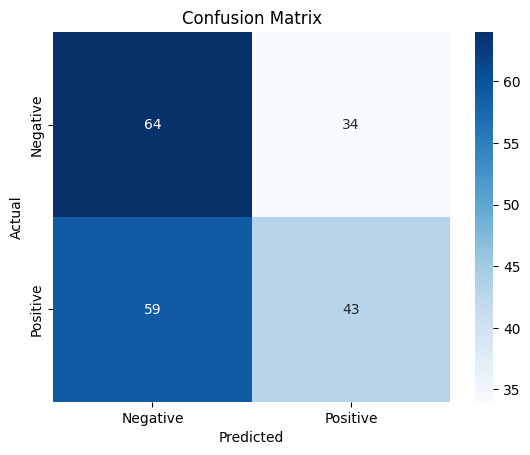

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true, predicted)
labels = ['Negative', 'Positive']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

 3. Посчитайте основные метрики качества классификатора:
 Accuracy (доля верно угаданных) sklearn.metrics.accuracy
 Precision (точность)
sklearn.metrics.accuracy.precision_score
 Recall (полнота) sklearn.metrics.recall_score
 F-мера sklearn.metrics.f1_score

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(true, predicted)
prec = precision_score(true, predicted)
rec = recall_score(true, predicted)
f1 = f1_score(true, predicted)

print(acc, prec, rec, f1)

0.535 0.5584415584415584 0.4215686274509804 0.48044692737430167


 4. Имеется четыре обученных классификатора. В файле scores.csv записаны истинные классы и значения степени принадлежности положительному классу для каждого классификатора на некоторой выборке: для логистической регрессии вероятность положительного класса (колонка score_logreg), для SVM отступ от разделяющей поверхности(колонка score_svm),для метрического алгоритма взвешенная сумма классов соседей (колонка score_knn), для решающего дерева доля положительных объектов в листе (колонка score_tree).
 Загрузите этот файл.

In [ ]:
scores = pd.read_csv("scores.csv")
true = scores['true']

 5. Посчитайте площадь под ROC-кривой для каждого классифика
тора. Какой классификатор имеет наибольшее значение метрики
 AUC-ROC (укажите название столбца с ответами этого классифи
катора)? Воспользуйтесь функцией sklearn.metrics.roc_auc_score.


In [ ]:
from sklearn.metrics import roc_auc_score

auc_logreg = roc_auc_score(true, scores['score_logreg'])
auc_svm = roc_auc_score(true, scores['score_svm'])
auc_knn = roc_auc_score(true, scores['score_knn'])
auc_tree = roc_auc_score(true, scores['score_tree'])

print(auc_logreg, auc_svm, auc_knn, auc_tree)

auc_scores = {
    'score_logreg': auc_logreg,
    'score_svm': auc_svm,
    'score_knn': auc_knn,
    'score_tree': auc_tree,
}

best_auc_classifier = max(auc_scores, key=auc_scores.get)
print(best_auc_classifier, max(auc_scores.items(), key=lambda x: x[1])[1])


0.719187675070028 0.7086834733893557 0.6351540616246498 0.6919267707082833
score_logreg 0.719187675070028


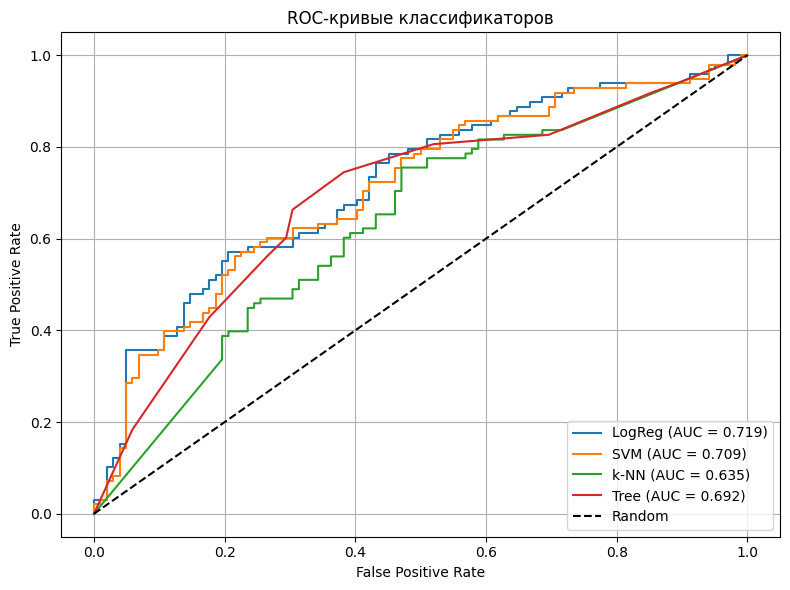

In [ ]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(true, scores['score_logreg'])
fpr_svm, tpr_svm, _ = roc_curve(true, scores['score_svm'])
fpr_knn, tpr_knn, _ = roc_curve(true, scores['score_knn'])
fpr_tree, tpr_tree, _ = roc_curve(true, scores['score_tree'])

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'LogReg (AUC = {auc_logreg:.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot(fpr_knn, tpr_knn, label=f'k-NN (AUC = {auc_knn:.3f})')
plt.plot(fpr_tree, tpr_tree, label=f'Tree (AUC = {auc_tree:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые классификаторов')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


 6. Какой классификатор достигает наибольшей точности (Precision)
 при полноте (Recall) не менее 70% (укажите название столбца с от
ветами этого классификатора)? Какое значение точности при этом
 получается?

In [ ]:
from sklearn.metrics import precision_recall_curve

classifiers = ['score_logreg', 'score_svm', 'score_knn', 'score_tree']
best_precision = 0
best_classifier = None

for clf in classifiers:
    precision, recall, thresholds = precision_recall_curve(true, scores[clf])
    max_prec = max([p for p, r in zip(precision, recall) if r >= 0.7], default=0)

    if max_prec > best_precision:
        best_precision = max_prec
        best_classifier = clf

print(best_classifier, round(best_precision, 2))

score_tree 0.65
